In [2]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    !pip install pyodbc
!pip install pandas
!pip install scikit-learn

In [4]:
import pyodbc
import pandas as pd
import csv

# Konfiguracja połączenia zapisana w formie słownika
connection_config = {
    'server': 'analityk.wwsi.edu.pl,50221',
    'database': 'synop',
    'user': 'student',
    'password': 'ciekawski',
    'encrypt': 'yes',  # Lub 'no', w zależności od konfiguracji serwera
    'trust_server_certificate': 'yes',  # Lub 'no', w zależności od konfiguracji serwera
    'driver': '{ODBC Driver 17 for SQL Server}',  # To jest nazwa sterownika ODBC
    'autocommit': True  # Opcjonalnie, jeśli chcesz włączyć tryb autocommit
}

# Tworzenie łańcucha połączenia z konfiguracji
connection_string = (
    f"DRIVER={connection_config['driver']};"
    f"SERVER={connection_config['server']};"
    f"DATABASE={connection_config['database']};"
    f"UID={connection_config['user']};"
    f"PWD={connection_config['password']};"
    f"Encrypt={connection_config['encrypt']};"
    f"TrustServerCertificate={connection_config['trust_server_certificate']};"
)

try:
    # Nawiązanie połączenia
    conn = pyodbc.connect(connection_string)

    # Wykonanie operacji na bazie danych
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM [Synop].[dbo].[DaneModelTMP]")
    rows = cursor.fetchall()
    # for row in rows:
    # Zapisz wyniki do pliku CSV

    with open('DaneModelTMP_baza.csv_', 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        csv_writer.writerow([i[0] for i in cursor.description])  # Nagłówki kolumn
        csv_writer.writerows(rows)  # Dane

except pyodbc.Error as ex:
    print(f"Błąd połączenia: {ex}")

finally:
    if 'conn' in locals():
        conn.close()

Błąd połączenia: ('01000', "[01000] [unixODBC][Driver Manager]Can't open lib '/opt/microsoft/msodbcsql17/lib64/libmsodbcsql-17.4.so.1.1' : file not found (0) (SQLDriverConnect)")


In [50]:
# import pyodbc
# import pandas as pd
# import csv

# # Konfiguracja połączenia zapisana w formie słownika
# connection_config = {
#     'server': 'analityk.wwsi.edu.pl,50221',
#     'database': 'synop',
#     'user': 'student',
#     'password': 'ciekawski',
#     'encrypt': 'yes',  # Lub 'no', w zależności od konfiguracji serwera
#     'trust_server_certificate': 'yes',  # Lub 'no', w zależności od konfiguracji serwera
#     'driver': '{ODBC Driver 18 for SQL Server}',  # To jest nazwa sterownika ODBC
#     'autocommit': True  # Opcjonalnie, jeśli chcesz włączyć tryb autocommit
# }

# # Tworzenie łańcucha połączenia z konfiguracji
# connection_string = (
#     f"DRIVER={connection_config['driver']};"
#     f"SERVER={connection_config['server']};"
#     f"DATABASE={connection_config['database']};"
#     f"UID={connection_config['user']};"
#     f"PWD={connection_config['password']};"
#     f"Encrypt={connection_config['encrypt']};"
#     f"TrustServerCertificate={connection_config['trust_server_certificate']};"
# )

# # Nawiązanie połączenia
# conn = pyodbc.connect(connection_string)

# # Wykonanie operacji na bazie danych
# #cursor = conn.cursor()
# #    cursor.execute("SELECT * FROM [Synop].[dbo].[DaneModelTMP] Where Pred6 > -1 and data > '20000101'")
# #    rows = cursor.fetchall()
#     # for row in rows:
# query = "SELECT * FROM [Synop].[dbo].[DaneModelTMP] Where Pred6 > -1 and data > '20000101'"
# df = pd.read_sql(query, conn)
#     # Zapisz wyniki do pliku CSV
# print(df.head())
# conn.close()

In [1]:
import warnings
import cudf
import pandas as pd
from io import StringIO
warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
df = cudf.read_csv('DaneModelTMP.csv', delimiter=',')

In [2]:
import warnings
import cudf
import pandas as pd
from io import StringIO
warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
df = cudf.read_csv('DaneModelTMP.csv', delimiter=',')

In [3]:
df.isnull()

,czas,data,Pora,miesiac,Widz3,Widz6,Zachm3,Zachm6,ZachmN3,ZachmN6,...,OpadM_E,OpadM_N,OpadM_S,Przelotny_W,Przelotny_E,Przelotny_N,Przelotny_S,Pred3,Pred6,id
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152765,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
152766,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
152767,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
152768,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [4]:
#!pip install sqlalchemy

In [5]:
df.shape

(152770, 62)

In [6]:
df.Widz3

0         30000
1         20000
2         30000
3         30000
4         30000
          ...  
152765     2266
152766     2533
152767     2800
152768     2500
152769     1900
Name: Widz3, Length: 152770, dtype: int64

In [7]:
df.drop(['Pred3'], axis=1, inplace=True)

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Załadowanie zbioru danych
list_col = list(df.columns.values)

X, y = df[['Pora', 'Zachm3', \
       'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
       'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
       'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
       'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
       'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
       'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
       'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
       'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
       'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
       'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
       'Przelotny_S']], df.Pred6

# Podziel dane na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicjalizuj model k-NN z 3 sąsiadami
knn = KNeighborsClassifier(n_neighbors=3)

# Trenuj model na danych treningowych
knn.fit(X_train, y_train)

# Przewiduj klasy na danych testowych
y_pred = knn.predict(X_test)

# Oblicz dokładność modelu
accuracy = accuracy_score(y_test, y_pred)
print("Dokładność modelu: {:.2f}".format(accuracy))


Dokładność modelu: 0.80


Testujemy model z 1 sąsiadami
Testujemy model z 2 sąsiadami
Testujemy model z 3 sąsiadami
Testujemy model z 4 sąsiadami
Testujemy model z 5 sąsiadami
Testujemy model z 6 sąsiadami
Testujemy model z 7 sąsiadami
Testujemy model z 8 sąsiadami
Testujemy model z 9 sąsiadami
Testujemy model z 10 sąsiadami
Testujemy model z 11 sąsiadami
Testujemy model z 12 sąsiadami
Testujemy model z 13 sąsiadami
Testujemy model z 14 sąsiadami
Testujemy model z 15 sąsiadami
Testujemy model z 16 sąsiadami
Testujemy model z 17 sąsiadami
Testujemy model z 18 sąsiadami
Testujemy model z 19 sąsiadami
Testujemy model z 20 sąsiadami


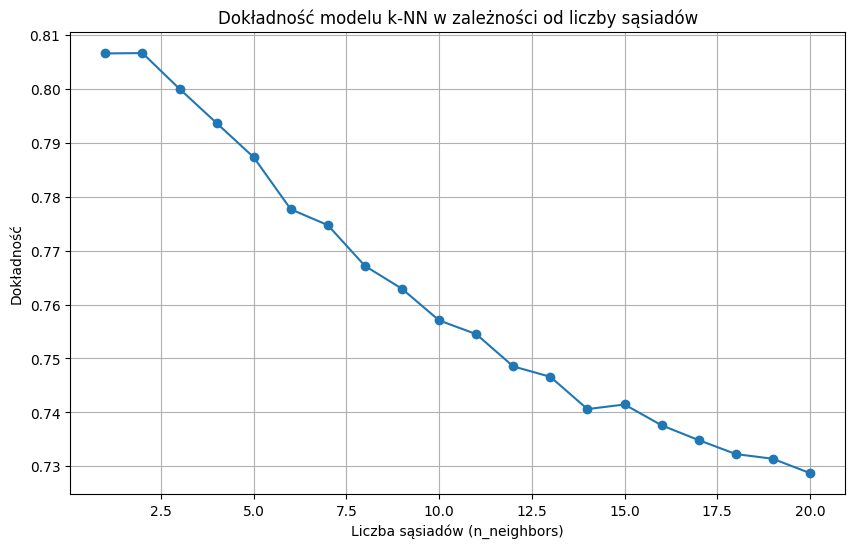

In [35]:
import matplotlib.pyplot as plt
# Przygotuj listy do przechowywania wyników
neighbors = range(1, 21)  # Testujemy od 1 do 20 sąsiadów
accuracies = []

# Testujemy różne wartości n_neighbors
for n in neighbors:
    print(f"Testujemy model z {n} sąsiadami")
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)


# Wyświetl wykres dokładności w zależności od liczby sąsiadów
plt.figure(figsize=(10, 6))
plt.plot(neighbors, accuracies, marker='o', linestyle='-')
plt.title('Dokładność modelu k-NN w zależności od liczby sąsiadów')
plt.xlabel('Liczba sąsiadów (n_neighbors)')
plt.ylabel('Dokładność')
plt.grid(True)
plt.show()

In [12]:
!pip install xgboost scikit-learn

/bin/bash: /home/miniyoda87/anaconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


1. Bagging: Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def train_random_forest(X_train, y_train):
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    return model

X, y = df[['Pora', 'Zachm3', \
       'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
       'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
       'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
       'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
       'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
       'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
       'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
       'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
       'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
       'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
       'Przelotny_S']], df.Pred6

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_random_forest(X_train, y_train)

RandomForestClassifier(random_state=42)

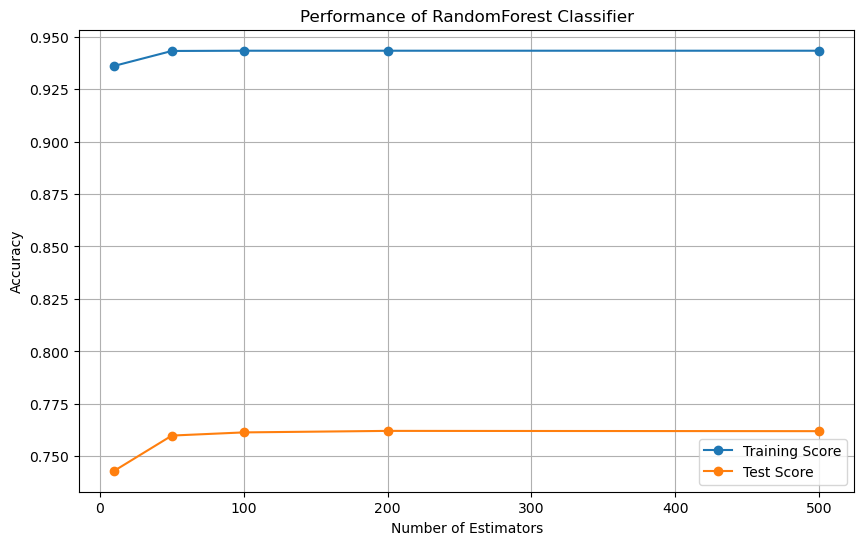

In [16]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Załaduj dane
X, y = df[['Pora', 'Zachm3', \
       'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
       'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
       'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
       'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
       'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
       'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
       'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
       'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
       'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
       'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
       'Przelotny_S']], df.Pred6

# Podziel dane
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

n_estimators_list = [10, 50, 100, 200, 500]
train_scores = []
test_scores = []

for n in n_estimators_list:
    # Trenuj model
    clf = RandomForestClassifier(n_estimators=n, random_state=42)
    clf.fit(X_train, y_train)
    
    # Zbierz wyniki
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

# Rysowanie wykresu
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, train_scores, label='Training Score', marker='o')
plt.plot(n_estimators_list, test_scores, label='Test Score', marker='o')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Performance of RandomForest Classifier')
plt.legend()
plt.grid(True)
plt.show()


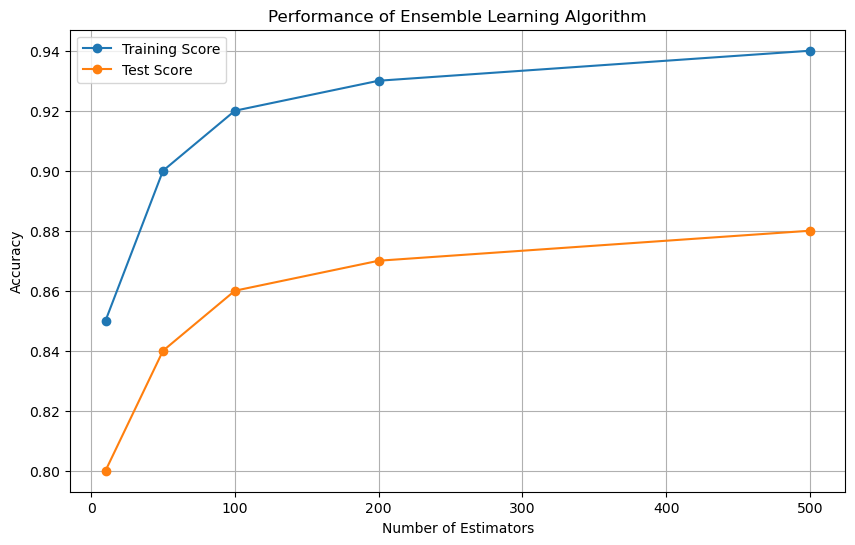

In [14]:
import matplotlib.pyplot as plt

# Przykładowe dane
n_estimators = [10, 50, 100, 200, 500]
train_scores = [0.85, 0.9, 0.92, 0.93, 0.94]
test_scores = [0.8, 0.84, 0.86, 0.87, 0.88]

# Rysowanie wykresu
plt.figure(figsize=(10, 6))
plt.plot(n_estimators, train_scores, label='Training Score', marker='o')
plt.plot(n_estimators, test_scores, label='Test Score', marker='o')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Performance of Ensemble Learning Algorithm')
plt.legend()
plt.grid(True)
plt.show()


2. Boosting: AdaBoost

In [49]:
from sklearn.ensemble import AdaBoostClassifier

def train_adaboost(X_train, y_train):
    model = AdaBoostClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    return model

X, y = df[['Pora', 'Zachm3', \
       'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
       'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
       'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
       'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
       'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
       'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
       'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
       'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
       'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
       'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
       'Przelotny_S']], df.Pred6

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


f_X_train = X_train.to_numpy()
f_y_train = y_train.to_numpy()

f_X_train = f_X_train.astype(np.float64)
f_y_train = f_y_train.astype(np.float64)

train_adaboost(f_X_train, f_y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

3. Stacking

### cuml ensamble models PogodynkAI

In [3]:
!pip install scikit-learn
!pip install dask
!python3 -m pip install tensorflow[and-cuda]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 8.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 5.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 9.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.5/728.5 MB 3.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 13.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 10.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 8.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.3/210.3 MB 6.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 12.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 13.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 549.5/549.5 MB 1.7 MB/s eta 0:00:0000:0100:01

### Predykcja Pogody algorytmami Klasyfikacyjnymi

In [3]:
!python3 -c "import tensorflow as tf; print(tf.config.list_physical_devices('GPU'))"

2023-12-09 06:50:19.087003: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-12-09 06:50:19.087053: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-12-09 06:50:19.087075: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-12-09 06:50:19.092032: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-12-09 06:50:19.942579: W tensorflow/compiler/

In [4]:
import tensorflow as tf
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
# Lista urządzeń GPU
gpus = tf.config.list_physical_devices('GPU')

# Sprawdzenie, czy GPU są dostępne
if gpus:
    try:
        # Aby uzyskać więcej informacji o każdym GPU
        for gpu in gpus:
            print(gpu)
            # W TensorFlow 2.x można również użyć tf.config.experimental.get_device_details
            print("Nazwa:", tf.config.experimental.get_device_details(gpu)['device_name'])
    except RuntimeError as e:
        # Wyjątek może wystąpić, jeśli lista urządzeń jest pobierana po inicjalizacji GPU
        print(e)
else:
    print("GPU nie znaleziono.")

PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Nazwa: NVIDIA GeForce RTX 4090


2023-12-09 06:50:23.024161: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [5]:
import pandas as pd
import warnings
import cupy as cp
import rmm
warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
rmm.reinitialize(managed_memory=True)
cp.cuda.set_allocator(rmm.rmm_cupy_allocator)

/opt/conda/envs/rapids/lib/python3.10/site-packages/rmm/__init__.py:56: FutureWarning: Use of 'rmm.rmm_cupy_allocator' is deprecated and will be removed. 'rmm_cupy_allocator' now lives in the 'rmm.allocators.cupy' sub-module, please update your imports.
  warnings.warn(


In [6]:
#!pip install dask-cudf

In [120]:
import warnings
import os
import cupy as cp
import pandas as pd
import cudf
import dask_cudf
import pandas as pd
from io import StringIO
warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
df = cudf.read_csv('DaneModelTMP.csv', delimiter=',')

In [121]:
df

,czas,data,Pora,miesiac,Widz3,Widz6,Zachm3,Zachm6,ZachmN3,ZachmN6,...,OpadM_E,OpadM_N,OpadM_S,Przelotny_W,Przelotny_E,Przelotny_N,Przelotny_S,Pred3,Pred6,id
0,2013-08-06 04:00:00,2013-08-06,1,8,30000,30000,0.000000,0.000000,0.000000,0.000000,...,0,0,0,0,0,0,0,-1,0,169
1,2013-08-06 08:00:00,2013-08-06,2,8,20000,23333,1.000000,0.500000,0.000000,0.000000,...,0,0,0,0,0,0,0,-1,0,170
2,2013-08-06 12:00:00,2013-08-06,3,8,30000,26666,2.333333,1.833333,1.333333,0.833333,...,0,0,0,0,0,0,0,-1,0,171
3,2013-08-06 16:00:00,2013-08-06,4,8,30000,30000,2.666666,2.666666,1.666666,1.666666,...,0,0,0,0,0,0,0,-1,0,172
4,2013-08-06 20:00:00,2013-08-06,5,8,30000,30000,2.000000,2.166666,1.000000,1.166666,...,0,0,0,0,0,0,0,-1,0,173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152765,2022-12-21 23:00:00,2022-12-21,5,12,2266,3216,8.000000,8.000000,8.000000,7.666666,...,0,0,0,1,0,0,0,-1,2,180009
152766,2022-12-22 00:00:00,2022-12-22,0,12,2533,2883,8.000000,8.000000,7.666666,7.666666,...,0,0,0,0,0,0,0,-1,2,180010
152767,2022-12-22 01:00:00,2022-12-22,0,12,2800,2750,8.000000,8.000000,7.333333,7.666666,...,0,0,0,0,0,1,0,-1,2,180011
152768,2022-12-22 02:00:00,2022-12-22,0,12,2500,2383,8.000000,8.000000,7.000000,7.500000,...,0,0,0,0,0,1,0,-1,2,180012


In [122]:
df.count

<bound method DataFrame.count of                        czas        data  Pora  miesiac  Widz3  Widz6  \
0       2013-08-06 04:00:00  2013-08-06     1        8  30000  30000   
1       2013-08-06 08:00:00  2013-08-06     2        8  20000  23333   
2       2013-08-06 12:00:00  2013-08-06     3        8  30000  26666   
3       2013-08-06 16:00:00  2013-08-06     4        8  30000  30000   
4       2013-08-06 20:00:00  2013-08-06     5        8  30000  30000   
...                     ...         ...   ...      ...    ...    ...   
152765  2022-12-21 23:00:00  2022-12-21     5       12   2266   3216   
152766  2022-12-22 00:00:00  2022-12-22     0       12   2533   2883   
152767  2022-12-22 01:00:00  2022-12-22     0       12   2800   2750   
152768  2022-12-22 02:00:00  2022-12-22     0       12   2500   2383   
152769  2022-12-22 03:00:00  2022-12-22     0       12   1900   2216   

          Zachm3    Zachm6   ZachmN3   ZachmN6  ...  OpadM_E  OpadM_N  \
0       0.000000  0.000000  0

Pred6 - oznaczenia 

0 - brak zjawisk 

1 - mgła 

2 - Mżawka 

3 - burza 

4 - deszcz 

5 - śnieg 

6 - opad marznący  

7 - opad przelotny  

-9 - błąd 

‘accuracy’

metrics.accuracy_score

‘balanced_accuracy’

metrics.balanced_accuracy_score

‘top_k_accuracy’

metrics.top_k_accuracy_score

‘average_precision’

metrics.average_precision_score

‘neg_brier_score’

metrics.brier_score_loss

‘f1’

metrics.f1_score

for binary targets

‘f1_micro’

metrics.f1_score

micro-averaged

‘f1_macro’

metrics.f1_score

macro-averaged

‘f1_weighted’

metrics.f1_score

weighted average

‘f1_samples’

metrics.f1_score

by multilabel sample

‘neg_log_loss’

metrics.log_loss

requires predict_proba support

‘precision’ etc.

metrics.precision_score

suffixes apply as with ‘f1’

‘recall’ etc.

metrics.recall_score

suffixes apply as with ‘f1’

‘jaccard’ etc.

metrics.jaccard_score

suffixes apply as with ‘f1’

‘roc_auc’

metrics.roc_auc_score

‘roc_auc_ovr’

metrics.roc_auc_score

‘roc_auc_ovo’

metrics.roc_auc_score

‘roc_auc_ovr_weighted’

metrics.roc_auc_score

‘roc_auc_ovo_weighted’

metrics.roc_auc_score



In [ ]:
import numpy as np
import warnings
import cuml
warnings.filterwarnings("ignore")
from sklearn.ensemble import (RandomForestClassifier as RandomForestClassifier_gpu)
from sklearn.ensemble import (StackingClassifier as StackingClassifier_gpu)
from sklearn.tree import (DecisionTreeClassifier as DecisionTreeClassifier_gpu)
from sklearn.metrics import roc_curve, auc, roc_auc_score, balanced_accuracy_score, f1_score, roc_auc_score
from cuml.naive_bayes import GaussianNB
from cuml.cluster import DBSCAN
from cuml import SVC
from sklearn.ensemble import (GradientBoostingClassifier as GradientBoostingClassifier_gpu)
from cuml.svm import LinearSVC
from cuml.neighbors import (KNeighborsClassifier as KNeighborsClassifier_gpu)
from sklearn.ensemble import (AdaBoostClassifier as AdaBoostClassifier_gpu)
from cuml import MultinomialNB
from sklearn import model_selection
# from cuml.model_selection.model_selection import *
from cuml.model_selection import train_test_split
from cuml.linear_model import Lasso
from cuml.common.device_selection import using_device_type, set_global_device_type
# cuml.set_global_output_type('cudf')

# Create instances of the estimators
rf = RandomForestClassifier_gpu()
dtree = DecisionTreeClassifier_gpu()
gnb = GaussianNB()
dbscan = DBSCAN()  # Assuming you want to use DBSCAN as an estimator, which is unusual
knc = KNeighborsClassifier_gpu(n_neighbors=3)
la = Lasso()
svc = SVC()
lsvc = LinearSVC()
nbc = GaussianNB()
adac = AdaBoostClassifier_gpu()
mnb = MultinomialNB()
gbc = GradientBoostingClassifier_gpu()

# List of (name, estimator) tuples
def TestowanieModeli(X,y, out_dtype='float64'):
    dfs=[]
    wyniki=[]
    lista_estymatorow = [
        ('rfc', rf),
        ('Dtreec', dtree),
        ('adac', adac),
        ('gbc', gbc),
        ('gnb', gnb),
        ('knc', knc)
        # ('mnb', mnb),
        # ('la', la)
    ]

# Create the StackingClassifier
    miary=['accuracy','r2', 'balanced_accuracy', 'f1', 'roc_auc', 'roc_auc_ovo', 'roc_auc_ovr_weighted', 'roc_auc_ovo_weighted']
    for nazwa, model in lista_estymatorow:
        podzial=model_selection.KFold(n_splits=5,shuffle=True,random_state=125)
        with using_device_type('gpu'):
            # history = model.fit(X,y)
            cv_wynik=model_selection.cross_validate(model,X,y,cv= podzial,scoring= miary, verbose=1)
            wyniki.append(cv_wynik)
            df=pd.DataFrame(cv_wynik)
            df['model']= nazwa
            dfs.append(df)
    # model = stack_clf = StackingClassifier_gpu(estimators=lista_estymatorow)
    final=pd.concat(dfs)
    return final, cv_wynik, lista_estymatorow

y = []

X, y = df[['Pora', \
'Zachm6', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
'Wiatr_W', 'TemperaturaPowietrza', 'DeltaTemp6', \
'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', \
'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
'Przelotny_S']], df.Pred6

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

f_X_train = X_train.to_numpy()
f_y_train = y_train.to_numpy()

f_X_train = f_X_train.astype(np.float64)
f_y_train = f_y_train.astype(np.float64)

wynik_koncowy, cv_wynik, lista_estymatorow = TestowanieModeli(f_X_train, f_y_train, out_dtype='float64')
print(wynik_koncowy)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.7min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    9.7s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   41.8s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


In [35]:
type(wynik_koncowy)

pandas.core.frame.DataFrame

In [4]:
wynik_koncowy.to_csv('wyniki_walidacji_krzyzowej.csv', index=False)

NameError: name 'wynik_koncowy' is not defined

In [37]:
from joblib import dump

for nazwa, model in lista_estymatorow:
    dump(model, f'{nazwa}_model.joblib')

In [38]:
from joblib import load

model = load(f'{nazwa}_model.joblib')

In [5]:
wynik_koncowy = pd.read_csv('wyniki_walidacji_krzyzowej.csv', delimiter=',')

<Axes: xlabel='model', ylabel='test_r2'>

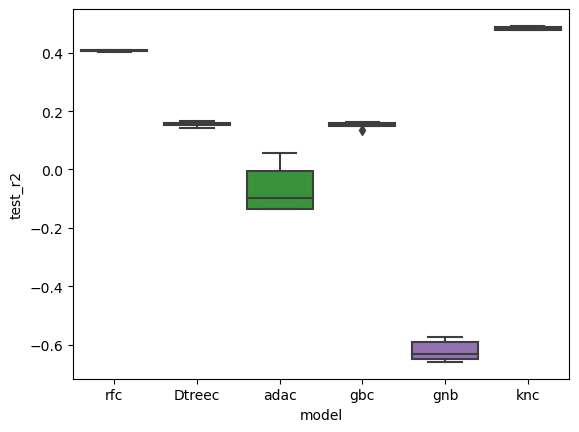

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x='model' ,y='test_r2', data=wynik_koncowy)

<Axes: xlabel='model', ylabel='test_accuracy'>

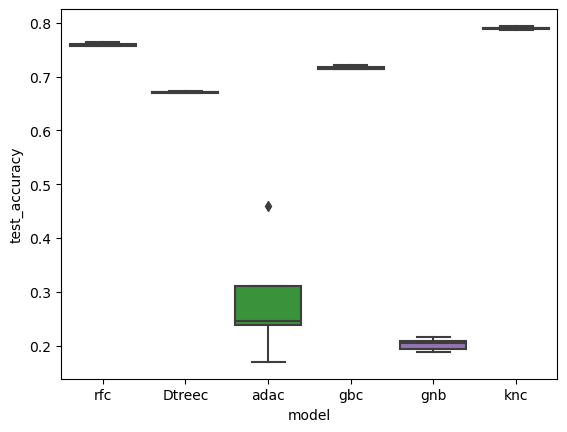

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x='model' ,y='test_accuracy', data=wynik_koncowy)

In [50]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

<Axes: xlabel='model', ylabel='test_f1'>

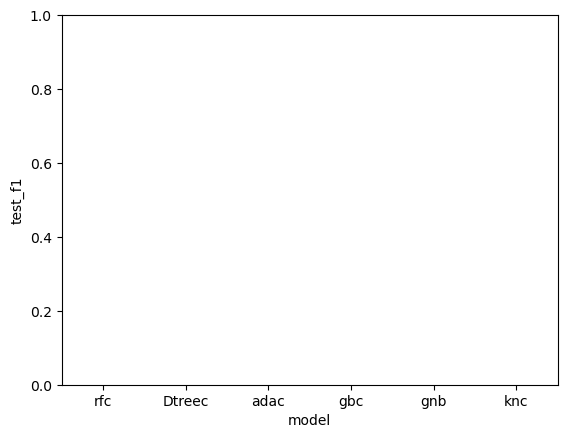

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x='model' ,y='test_f1', data=wynik_koncowy)

<Axes: xlabel='model', ylabel='test_balanced_accuracy'>

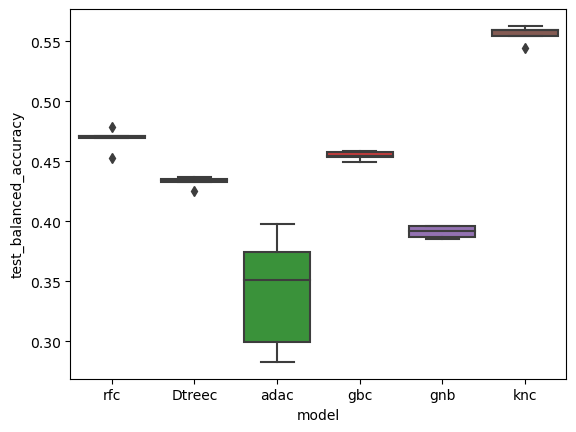

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x='model' ,y='test_balanced_accuracy', data=wynik_koncowy)

'roc_auc', 'roc_auc_ovo', 'roc_auc_ovr_weighted', 'roc_auc_ovo_weighted'

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x='model' ,y='test_roc_auc', data=wynik_koncowy)

<Axes: xlabel='model', ylabel='test_roc_auc_ovo'>

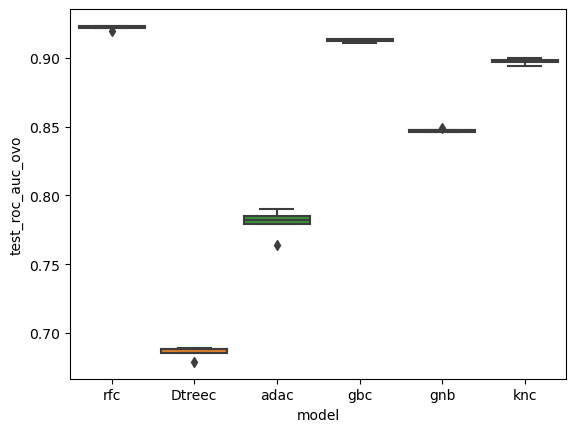

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x='model' ,y='test_roc_auc_ovo', data=wynik_koncowy)

<Axes: xlabel='model', ylabel='test_roc_auc_ovr_weighted'>

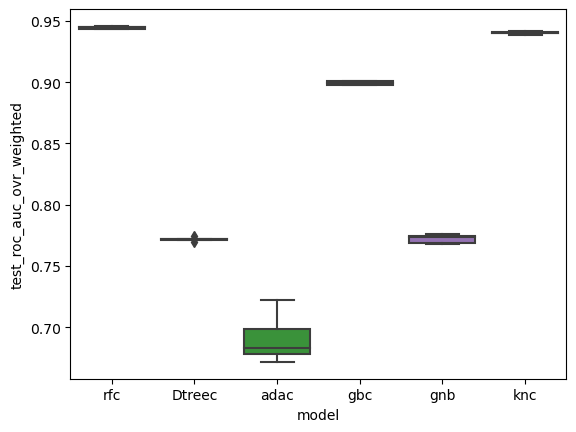

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x='model' ,y='test_roc_auc_ovr_weighted', data=wynik_koncowy)

<Axes: xlabel='model', ylabel='test_roc_auc_ovo_weighted'>

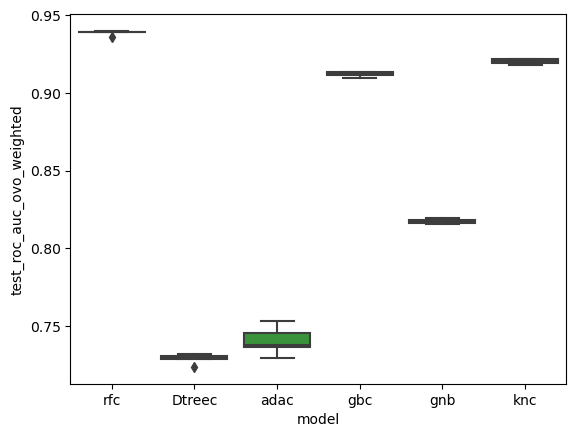

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x='model' ,y='test_roc_auc_ovo_weighted', data=wynik_koncowy)

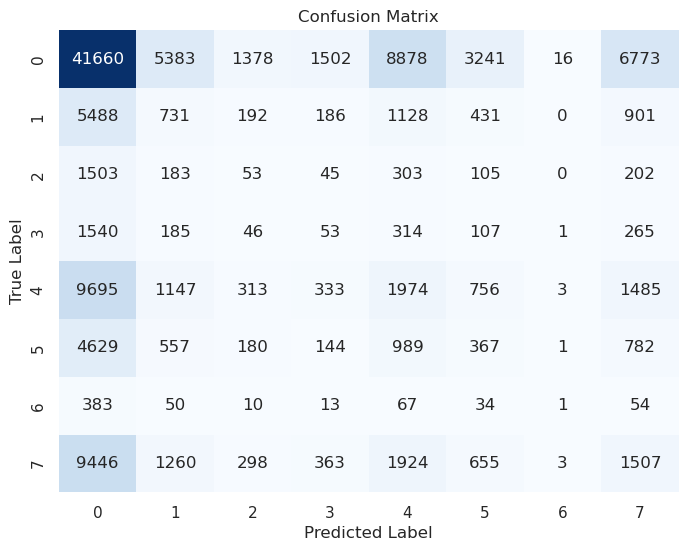

In [57]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(f_y_train, df.Pred6.head(122216).to_numpy())
# Set the context for the plot
sns.set(context='notebook', style='whitegrid')

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Add labels and title (optional)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')

# Show the plot
plt.show()

### Test Balanced Data

In [89]:
df

,czas,data,Pora,miesiac,Widz3,Widz6,Zachm3,Zachm6,ZachmN3,ZachmN6,...,OpadM_N,OpadM_S,Przelotny_W,Przelotny_E,Przelotny_N,Przelotny_S,Pred3,Pred6,id,Widz6_balance
0,2013-08-06 04:00:00,2013-08-06,1,8,30000,30000,0.000000,0.000000,0.000000,0.000000,...,0,0,0,0,0,0,-1,0,169,30000.0
1,2013-08-06 08:00:00,2013-08-06,2,8,20000,23333,1.000000,0.500000,0.000000,0.000000,...,0,0,0,0,0,0,-1,0,170,23333.0
2,2013-08-06 12:00:00,2013-08-06,3,8,30000,26666,2.333333,1.833333,1.333333,0.833333,...,0,0,0,0,0,0,-1,0,171,26666.0
3,2013-08-06 16:00:00,2013-08-06,4,8,30000,30000,2.666666,2.666666,1.666666,1.666666,...,0,0,0,0,0,0,-1,0,172,30000.0
4,2013-08-06 20:00:00,2013-08-06,5,8,30000,30000,2.000000,2.166666,1.000000,1.166666,...,0,0,0,0,0,0,-1,0,173,30000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152765,2022-12-21 23:00:00,2022-12-21,5,12,2266,3216,8.000000,8.000000,8.000000,7.666666,...,0,0,1,0,0,0,-1,2,180009,NaN
152766,2022-12-22 00:00:00,2022-12-22,0,12,2533,2883,8.000000,8.000000,7.666666,7.666666,...,0,0,0,0,0,0,-1,2,180010,NaN
152767,2022-12-22 01:00:00,2022-12-22,0,12,2800,2750,8.000000,8.000000,7.333333,7.666666,...,0,0,0,0,1,0,-1,2,180011,NaN
152768,2022-12-22 02:00:00,2022-12-22,0,12,2500,2383,8.000000,8.000000,7.000000,7.500000,...,0,0,0,0,1,0,-1,2,180012,NaN


In [90]:
df['Pred6'].unique()

array([0, 1, 3, 7, 4, 2, 5, 6])

In [91]:
df = df.to_pandas()

AttributeError: 'DataFrame' object has no attribute 'to_pandas'

In [92]:
# X, y = df[['Pora', \
# 'Zachm6', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
# 'Wiatr_W', 'TemperaturaPowietrza', 'DeltaTemp6', \
# , 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
# 'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
# 'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
# 'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
# 'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
# 'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
# 'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
# 'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
# 'Przelotny_S']], df.Pred6

In [113]:
df['Widz6_balance'] = (df.loc[df['Pred6'] == 4, 'Widz6']).astype(int)
df.loc[df['Pred6'] == 4, 'Widz6']

85        19166
86        15833
87        10000
88        10833
89         6166
          ...  
152758    14000
152759    12333
152760    10416
152761     8583
152762     6750
Name: Widz6, Length: 19599, dtype: int64

In [95]:
# Create a vectorizer and train it
vectorizer = TfidfVectorizer()
matrix = vectorizer.fit_transform(df.Widz6.astype(str))

# Features are our matrix of tf-idf values
# labels are whether each recipe is Indian or not
X = matrix
y = df.Pred6

# How many are Indian?
y.value_counts()

0    85907
4    19599
7    19455
1    11269
5     9609
3     3148
2     3006
6      777
Name: Pred6, dtype: int64

In [97]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
matrix = vectorizer.fit_transform(df.Widz6.astype(str))
X = matrix
y = df.Pred6

In [98]:
from sklearn.model_selection import train_test_split
from collections import Counter
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)
print(f"Training target statistics: {Counter(y_train)}")
print(f"Testing target statistics: {Counter(y_test)}")

Training target statistics: Counter({0: 60131, 4: 13763, 7: 13540, 1: 7895, 5: 6695, 3: 2237, 2: 2097, 6: 581})
Testing target statistics: Counter({0: 25776, 7: 5915, 4: 5836, 1: 3374, 5: 2914, 3: 911, 2: 909, 6: 196})


In [118]:
!pip install scikit-plot

In [117]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from scikitplot.metrics import plot_cumulative_gain
from scikitplot.metrics import plot_lift_curve
from numpy import argmax
import numpy as np
def build_and_test(X_tr, X_te, y_tr, y_te, class_weight=None, threshold=False):
    
    # Build and Plot PCA
    pca = PCA(n_components=2)
    pca.fit(X_tr.toarray())
    X_pca = pca.transform(X_tr.toarray())
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_tr, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
    plt.show()
    
    # Build and fit the model
    if class_weight:
        model = DecisionTreeClassifier(class_weight=class_weight)
    else:
        model = DecisionTreeClassifier()
    model.fit(X_tr, y_tr)
    
    # Test the model
    y_pred = model.predict(X_te)
    print('Precision score %s' % precision_score(y_te, y_pred))
    print('Recall score %s' % recall_score(y_te, y_pred))
    print('F1-score score %s' % f1_score(y_te, y_pred))
    print('Accuracy score %s' % accuracy_score(y_te, y_pred))
    
    y_score = model.predict_proba(X_te)
    fpr0, tpr0, thresholds = roc_curve(y_te, y_score[:, 1])
    roc_auc0 = auc(fpr0, tpr0)
    
    # Calculate the best threshold
    best_threshold = None
    if threshold:
        J = tpr0 - fpr0
        ix = argmax(J) # take the value which maximizes the J variable
        best_threshold = thresholds[ix]
        # adjust score according to threshold.
        y_score = np.array([[1, y[1]] if y[0] >= best_threshold else [0, y[1]] for y in y_score])
        
    
    # Plot metrics 
    plot_roc(y_te, y_score)
    plt.show()
    
    plot_precision_recall(y_te, y_score)
    plt.show()
    
    plot_cumulative_gain(y_te, y_score)
    plt.show()
    
    plot_lift_curve(y_te, y_score)
    plt.show()
    
    # Print a classification report
    print(classification_report(y_te,y_pred))
    return roc_auc0,fpr0,tpr0, best_threshold

ModuleNotFoundError: No module named 'scikitplot'

In [87]:
print(len(X))
print(y)

152770
0         0
1         0
2         0
3         0
4         0
         ..
152765    2
152766    2
152767    2
152768    2
152769    2
Name: Pred6, Length: 152770, dtype: int64


In [88]:
df.Pred6

0         0
1         0
2         0
3         0
4         0
         ..
152765    2
152766    2
152767    2
152768    2
152769    2
Name: Pred6, Length: 152770, dtype: int64

In [12]:
y_test.values

array([0, 0, 3, ..., 0, 0, 5])

In [13]:
df_y_test = cudf.DataFrame()
df_y_test = y_test.to_frame()
df_wynik_koncowy = cudf.DataFrame()
df_wynik_koncowy = wynik_koncowy

In [14]:
type(y_test)

cudf.core.series.Series

In [15]:
df_wynik_koncowy

,fit_time,score_time,test_accuracy,test_r2,model
0,21.441311,0.501806,0.754173,0.392031,rfc
1,22.439229,0.523650,0.753754,0.392118,rfc
2,22.323431,0.515533,0.755799,0.396315,rfc
3,45.206119,1.671667,0.754858,0.386275,rfc
4,71.693028,1.673652,0.759277,0.388283,rfc
0,6.414592,0.023107,0.666667,0.133655,Dtreec
1,6.564776,0.024393,0.665098,0.132488,Dtreec
2,5.694706,0.023880,0.664076,0.146635,Dtreec
3,5.315456,0.025548,0.667267,0.144324,Dtreec
4,3.506710,0.008797,0.668330,0.138389,Dtreec


In [29]:
cv_wynik

{'fit_time': array([9.30730081, 0.45884871, 0.43557024, 0.46235728, 0.42743206]),
 'score_time': array([0.73249078, 0.32904696, 0.32717657, 0.32146621, 0.30429387]),
 'test_accuracy': array([0.26030928, 0.26788856, 0.23258193, 0.23491388, 0.25426502]),
 'test_r2': array([-0.51457317, -0.51063619, -0.50505065, -0.46997062, -0.54238199])}

In [30]:
X_test

,Pora,Zachm3,Zachm6,ZachmN3,ZachmN6,Wiatr_N,Wiatr_E,Wiatr_S,Wiatr_W,DeltaTemp3,...,Snieg_N,Snieg_S,OpadM_W,OpadM_E,OpadM_N,OpadM_S,Przelotny_W,Przelotny_E,Przelotny_N,Przelotny_S
14717,0,2.666666,4.000000,2.333333,3.833333,0.000,4.9240,0.8682,0.0000,-1.6,...,1,0,0,0,0,0,0,0,0,0
8044,0,0.000000,0.000000,0.000000,0.000000,0.000,1.8794,0.6840,0.0000,-1.1,...,0,0,0,0,0,0,0,0,0,0
116558,5,7.000000,7.000000,6.333333,4.333333,1.500,2.5981,0.0000,0.0000,-1.6,...,0,0,0,0,0,0,5,1,0,4
61485,2,8.000000,8.000000,7.000000,7.000000,0.000,5.9088,1.0419,0.0000,1.5,...,0,0,0,0,0,0,0,3,0,2
45556,4,2.666666,2.333333,2.666666,2.333333,0.866,0.5000,0.0000,0.0000,-4.1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43985,5,8.000000,8.000000,8.000000,8.000000,0.000,0.0000,0.9397,0.3420,-0.4,...,0,1,0,0,0,0,0,0,0,0
37080,0,0.000000,0.833333,0.000000,0.833333,0.000,0.0000,0.6946,3.9392,-0.3,...,0,0,0,0,0,0,0,0,0,1
134752,5,1.666666,0.833333,0.000000,0.000000,0.000,0.6428,0.7660,0.0000,-3.6,...,0,0,0,0,0,0,0,0,0,0
91940,0,0.000000,0.000000,0.000000,0.000000,0.000,0.0000,0.0000,0.0000,-2.8,...,0,0,0,0,0,0,0,0,0,0


In [16]:
df_y_test

,Pred6
14717,0
8044,0
116558,3
61485,4
45556,0
...,...
43985,1
37080,0
134752,0
91940,0


In [19]:
type(df_y_test)

cudf.core.dataframe.DataFrame

In [20]:
type(df_wynik_koncowy)

pandas.core.frame.DataFrame

In [21]:
wynik_df = cudf.DataFrame()
wynik_df = cudf.concat([df_wynik_koncowy, y_test])
wynik_df

TypeError: cannot concatenate object of type <class 'pandas.core.frame.DataFrame'>

Wyniki walidacji krzyżowej:
      fit_time  score_time  test_accuracy   test_r2   model
0   21.441311    0.501806       0.754173  0.392031     rfc
1   22.439229    0.523650       0.753754  0.392118     rfc
2   22.323431    0.515533       0.755799  0.396315     rfc
3   45.206119    1.671667       0.754858  0.386275     rfc
4   71.693028    1.673652       0.759277  0.388283     rfc
0    6.414592    0.023107       0.666667  0.133655  Dtreec
1    6.564776    0.024393       0.665098  0.132488  Dtreec
2    5.694706    0.023880       0.664076  0.146635  Dtreec
3    5.315456    0.025548       0.667267  0.144324  Dtreec
4    3.506710    0.008797       0.668330  0.138389  Dtreec
0   12.018652    0.224629       0.227704  0.003209    adac
1    8.887191    0.200010       0.494375 -0.149663    adac
2    8.634606    0.223306       0.311950 -0.035284    adac
3    8.575912    0.183541       0.243914 -0.007494    adac
4    8.332105    0.191337       0.531195 -0.245123    adac
0  246.414053    0.231396  

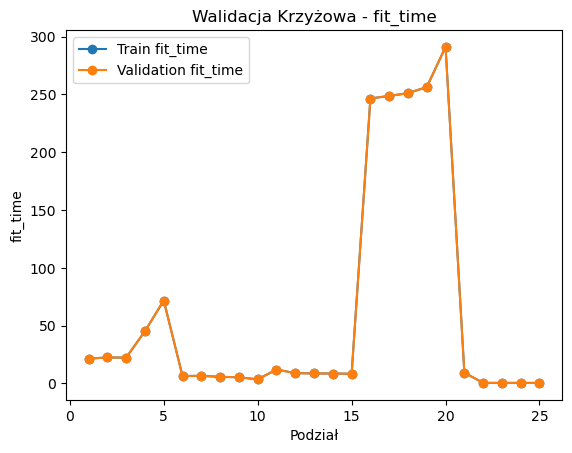

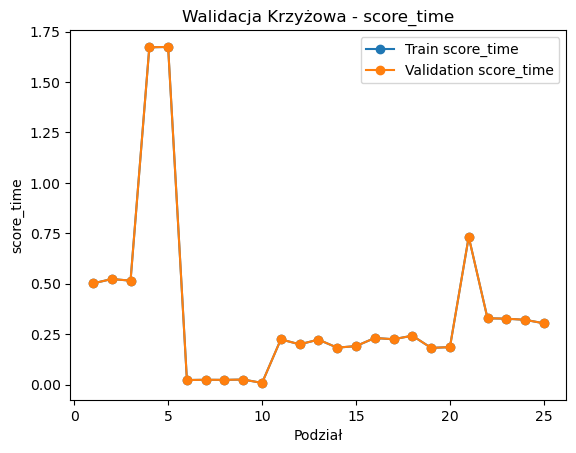

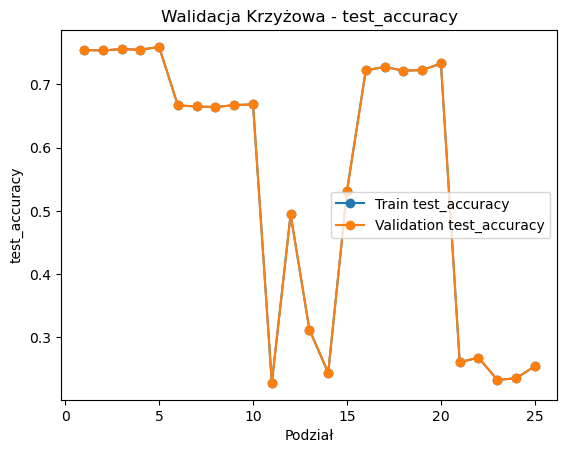

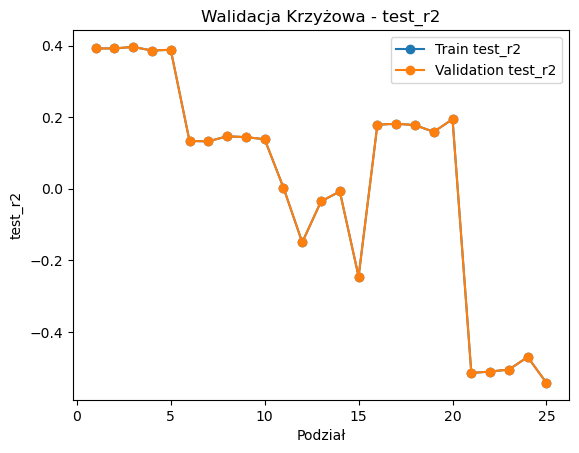

In [22]:
import matplotlib.pyplot as plt
print("Wyniki walidacji krzyżowej:\n", wynik_koncowy)

# Wykres dla każdej z metryk
for metric in cv_wynik:
    train_scores = wynik_koncowy[f'{metric}']
    test_scores = wynik_koncowy[f'{metric}']
    nazwa-modelu = range(1, len(train_scores) + 1)

    plt.figure()
    plt.plot(n_splits, train_scores, 'o-', label=f'Train {metric}')
    plt.plot(n_splits, test_scores, 'o-', label=f'Validation {metric}')
    plt.title(f'Walidacja Krzyżowa - {metric}')
    plt.xlabel('Podział')
    plt.ylabel(metric)
    plt.legend()
    plt.show()

In [23]:
print('df.Pred6',len(df.Pred6))
print('y_test',len(y_test))

df.Pred6 152770
y_test 30554


In [24]:
y_test

14717     0
8044      0
116558    3
61485     4
45556     0
         ..
43985     1
37080     0
134752    0
91940     0
63301     5
Name: Pred6, Length: 30554, dtype: int64

In [25]:
len(df)

152770

In [27]:
wynik_koncowy.values[0][1]

0.5251169204711914

In [28]:
len(wynik_koncowy)

20

In [60]:
import matplotlib.pyplot as plt
import numpy as np

data = list([])

# loading data
for i in range(len(wynik_koncowy)):
    for y in range(3):
        data = data.append(wynik_koncowy[i][y])

# Create a figure and a set of subplots
fig, ax = plt.subplots()

# Create a boxplot
ax.boxplot(data)

# Add title and labels
ax.set_title('Boxplot Example')
ax.set_ylabel('Values')

# Show the plot
plt.show()


KeyError: 0

In [30]:
model = cuml.LinearRegression(fit_intercept=True, normalize=True)
model.fit(X_train, y_train).predict(X_test)

14717    -0.229137
8044     -0.094693
116558    3.915746
61485     2.824356
45556     0.322417
            ...   
43985     1.509785
37080     0.280610
134752    0.096869
91940     0.363788
63301     4.058424
Length: 30554, dtype: float64

In [31]:
model = cuml.Lasso(fit_intercept=False, normalize=True)
model.fit(X_train, y_train).predict(X_test)

14717     0.0
8044      0.0
116558    0.0
61485     0.0
45556     0.0
         ... 
43985     0.0
37080     0.0
134752    0.0
91940     0.0
63301     0.0
Length: 30554, dtype: float64

In [32]:
model = cuml.LogisticClassifier(fit_intercept=True)
model.fit(X_train, y_train).predict(X_test)

AttributeError: module cuml has no attribute LogisticClassifier

In [33]:
model.predict_proba(X_test)

AttributeError: predict_proba

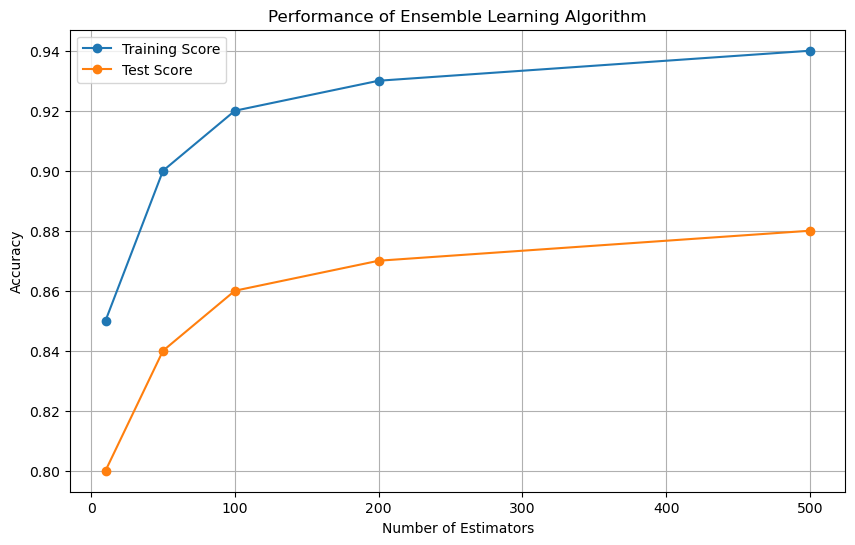

In [34]:
import matplotlib.pyplot as plt

# Przykładowe dane
n_estimators = [10, 50, 100, 200, 500]
train_scores = [0.85, 0.9, 0.92, 0.93, 0.94]
test_scores = [0.8, 0.84, 0.86, 0.87, 0.88]

# Rysowanie wykresu
plt.figure(figsize=(10, 6))
plt.plot(n_estimators, train_scores, label='Training Score', marker='o')
plt.plot(n_estimators, test_scores, label='Test Score', marker='o')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Performance of Ensemble Learning Algorithm')
plt.legend()
plt.grid(True)
plt.show()


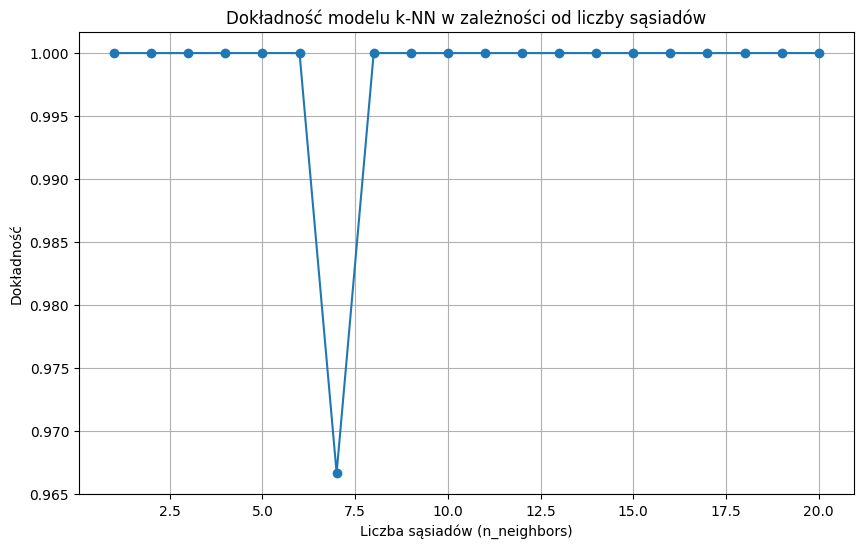

In [45]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Załaduj przykładowy zbiór danych (Iris dataset)
iris = load_iris()
X, y = iris.data, iris.target

# Podziel dane na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Przygotuj listy do przechowywania wyników
neighbors = range(1, 21)  # Testujemy od 1 do 20 sąsiadów
accuracies = []

# Testujemy różne wartości n_neighbors
for n in neighbors:
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

# Wyświetl wykres dokładności w zależności od liczby sąsiadów
plt.figure(figsize=(10, 6))
plt.plot(neighbors, accuracies, marker='o', linestyle='-')
plt.title('Dokładność modelu k-NN w zależności od liczby sąsiadów')
plt.xlabel('Liczba sąsiadów (n_neighbors)')
plt.ylabel('Dokładność')
plt.grid(True)
plt.show()


In [53]:
# import matplotlib.pyplot as plt
# from sklearn.datasets import make_blobs
# from sklearn.neighbors import NearestNeighbors

# # Tworzenie przykładowych danych
# X, y = df[['Pora', 'Zachm3', \
#        'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
#        'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
#        'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
#        'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
#        'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
#        'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
#        'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
#        'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
#        'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
#        'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
#        'Przelotny_S']], df.Pred6

# # Tworzenie modelu KNN
# k = 3
# knn = NearestNeighbors(n_neighbors=k)
# knn.fit(X)

# # Wykres
# plt.figure(figsize=(8, 6))

# # Wyznaczanie klastrów
# distances, indices = knn.kneighbors(X)
# for i in range(X.shape[0]):
#     for j in indices[i]:
#         plt.plot([X[i, 0], X[j, 0]], [X[i, 1], X[j, 1]], 'k--', alpha=0.3)

# # Wyświetlenie punktów danych
# plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis')
# plt.title(f"KNN Clusters (k={k})")
# plt.xlabel("Feature 1")
# plt.ylabel("Feature 2")
# plt.show()


In [5]:
!python3 -c "import tensorflow as tf; print(tf.config.list_physical_devices('GPU'))"

2023-11-26 10:08:18.022213: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-11-26 10:08:18.022261: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-11-26 10:08:18.022283: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-11-26 10:08:18.026995: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-11-26 10:08:18.884903: W tensorflow/compiler/

In [4]:
!nvidia-smi

Sun Nov 26 10:08:10 2023       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.29.04              Driver Version: 546.17       CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 4090        On  | 00000000:01:00.0  On |                  Off |
|  0%   50C    P5              28W / 450W |   2511MiB / 24564MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
# import matplotlib.pyplot as plt
# # Tworzenie wykresu dla predykcji kolejnych danych
# X_new = df[['id', 'Widz3']]

# # Przewidywanie klas na nowych danych
# y_new = knn.predict(X_new)

# print("Predykcje na nowych danych:")
# for i in range(len(X_new)):
#     print(f"Dane: {X_new[i]}, Predykcja klasy: {y_new[i]}")

# # Wykres klas
# plt.figure()
# plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.Set1, edgecolor='k')
# plt.xlabel('nr pomiaru')
# plt.ylabel('Predykcja widzialności na następne trzy godziny')

# plt.show()

In [29]:
# import matplotlib.pyplot as plt

# # Indeksy wybranych cech (pierwsza i druga kolumna)
# feature1 = [0,  1,  3]
# feature2 = [0,  1,  3]

# # Indeksy klas (unikalne wartości w y)
# classes = list(set(y))

# # Kolor każdej klasy
# colors = ['b', 'g', 'r']

# # Tytuł wykresu
# plt.title("K-NN Classification")

# # Rysowanie punktów danych
# for c in classes:
#     plt.scatter(X_test[y_test == c, feature1], X_test[y_test == c, feature2], c=colors[c], label="Class " + str(c))

# # Rysowanie punktów predykcji
# plt.scatter(X_test[:, feature1], X_test[:, feature2], c='k', marker='x', label="Predictions")

# plt.xlabel('nr pomiaru')
# plt.ylabel('Predictions')

# plt.legend(loc='best')

# plt.show()


In [47]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import StackingClassifier
# from sklearn.tree import DecisionTreeClassifier
# from cuml.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from sklearn import model_selection
# from sklearn.naive_bayes import GaussianNB
# # from cuml import KMeans
# from cuml.cluster import DBSCAN
# from cuml.decomposition import PCA
# from cuml.manifold import TSNE
# from cuml import DBSCAN as cumlDBSCAN
# from cuml.dask.ensemble import RandomForestClassifier as cuMLDaskRFClassifier
# from dask_ml.cluster import KMeans as skKMeans



# def EksperymentMLRegresja(X,y):
#     dfs=[]
#     wyniki=[]
#     models = [ 
#     ('rf', RandomForestClassifier(n_estimators=10, random_state=42)),
#     ('Dtree', DecisionTreeClassifier()),
#     #  ('lr', LogisticRegression()),
#     #  ('svc', SVC(probability=True)),  # Używamy implementacji SVC z sklearn, ponieważ cuml nie oferuje wsparcia dla SVC
#     ('gnb', GaussianNB()),
#     # ('KMeans', KMeans),
#     ('DBSCAN', DBSCAN),
#     # ('PCA', PCA),
#     ('KNC', KNeighborsClassifier)
#     ],
#     #wyniki=[]
#     scoring=['accuracy','r2']
#     for model in models:
#         podzial=model_selection.KFold(n_splits=10,shuffle=True,random_state=125)
#         model = StackingClassifier(estimators=models, final_estimator=LogisticRegression(), cv=5)
#         model.fit(X,y)
#         cv_wynik=model_selection.cross_validate(model,X,y,cv=podzial,scoring=scoring)
#         wyniki.append(cv_wynik)
#         df=pd.DataFrame(cv_wynik)
#         df['model']= model
#         dfs.append(df)
#     final=pd.concat(dfs,ignore_index=True)
#     return final

# X, y = df[['Pora', 'Zachm3', \
# 'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
# 'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
# 'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
# 'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
# 'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
# 'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
# 'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
# 'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
# 'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
# 'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
# 'Przelotny_S']], df.Pred6

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# f_X_train = X_train.to_numpy()
# f_y_train = y_train.to_numpy()

# final = EksperymentMLRegresja(f_X_train, f_y_train)
# print(final)

In [45]:
# from dask_cuda import LocalCUDACluster
# from dask.distributed import Client
# import dask_cudf
# from cuml.linear_model import Lasso
# from cuml.common.device_selection import using_device_type, set_global_device_type
# from cuml.model_selection import train_test_split
# from sklearn.ensemble import StackingClassifier
# from sklearn.tree import DecisionTreeRegressor
# from cuml.svm import SVC
# from sklearn import model_selection
# from cuml.naive_bayes import GaussianNB
# from cuml import KMeans
# from cuml.cluster import DBSCAN
# from cuml.decomposition import PCA
# from cuml.manifold import TSNE
# from cuml import DBSCAN as cumlDBSCAN
# from cuml import KNeighborsClassifier


# cluster = LocalCUDACluster()
# client = Client(cluster)


# def EksperymentMLRegresja(X,y):
#     dfs=[]
#     wyniki=[]
#     models = [
#     ('RFC', cuMLDaskRFClassifier()), 
#     # ('RFC', RandomForestClassifier()),
#     # ('Dtree', DecisionTreeClassifier()),
#     ('skk', skKMeans()),
#     ('NNC', KNeighborsClassifier()),
#     ],
#     #wyniki=[]
#     scoring=['accuracy','r2']
#     for model in models:
#         podzial=model_selection.KFold(n_splits=10,shuffle=True,random_state=125)
#         model = StackingClassifier(estimators=model, final_estimator=cuMLDaskRFClassifier(), cv=5)
#         model.fit(X,y)
#         cv_wynik=model_selection.cross_validate(model,X,y,cv=podzial,scoring=scoring)
#         wyniki.append(cv_wynik)
#         df=pd.DataFrame(cv_wynik)
#         df['model']= model
#         dfs.append(df)
#     final=pd.concat(dfs,ignore_index=True)
#     return final

# X, y = df[['Pora', 'Zachm3', \
# 'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
# 'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
# 'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
# 'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
# 'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
# 'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
# 'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
# 'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
# 'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
# 'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
# 'Przelotny_S']], df.Pred6

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# f_X_train = X_train.to_numpy()
# f_y_train = y_train.to_numpy()

# final = EksperymentMLRegresja(f_X_train, f_y_train)
# print(final)

In [47]:
# from sklearn.ensemble import StackingClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import train_test_split
# from sklearn.svm import SVC
# from sklearn.naive_bayes import GaussianNB

# def train_stacking(X_train, y_train):
#     estimators = [
#         ('lr', LogisticRegression(max_iter=1000, random_state=42)),
#         ('svc', SVC(probability=True, random_state=42)),
#         ('gnb', GaussianNB())
#     ]
#     model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=5)
#     progress = model.fit(X_train, y_train)
#     print(progress)
#     return model

# X, y = df[['Pora', 'Zachm3', \
#        'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
#        'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
#        'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
#        'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
#        'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
#        'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
#        'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
#        'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
#        'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
#        'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
#        'Przelotny_S']], df.Pred6

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train_stacking(X_train, y_train)

In [46]:
# import cuml
# from cuml.linear_model import LinearRegression, LogisticRegression
# from cuml.ensemble import RandomForestRegressor
# # from cuml.tree import DecisionTreeRegressor
# from sklearn.svm import SVC
# from sklearn.naive_bayes import GaussianNB
# from cuml.datasets import make_classification
# from cuml.metrics import accuracy_score
# from sklearn.ensemble import StackingRegressor

# # Generowanie danych
# X, y = df[['Pora', 'Zachm3', \
#        'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
#        'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
#        'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
#        'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
#        'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
#        'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
#        'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
#        'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
#        'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
#        'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
#        'Przelotny_S']], df.Pred6

# X_train, X_test = X[:800], X[800:]
# y_train, y_test = y[:800], y[800:]

# # Definicja modeli
# models = [
#     ('LinReg', LinearRegression()), 
#     ('RF', RandomForestRegressor(n_estimators=100, max_depth=5)),
#     # ('Dtree', DecisionTreeRegressor(max_depth=5)),
#     ('lr', LogisticRegression(max_iter=1000))
#     # Pozostałe modele nie są dostępne w cuML
# ]

# # Uczenie modelu składającego się
# # Uwaga: musisz użyć StackingRegressor z sklearn, ponieważ cuml nie oferuje go
# model = StackingRegressor(estimators=models, final_estimator=LinearRegression())
# model.fit(X_train, y_train)

# # Predykcje
# y_pred = model.predict(X_test)


In [52]:
# import xgboost as xgb
# from xgboost import DMatrix

# def trenuj_xgboost(X_train, y_train, X_test, y_test, parametry=None):
#     """
#     Trenuje model XGBoost na danych treningowych i ocenia na danych testowych.

#     Args:
#     - X_train (array-like): cechy danych treningowych
#     - y_train (array-like): etykiety danych treningowych
#     - X_test (array-like): cechy danych testowych
#     - y_test (array-like): etykiety danych testowych
#     - parametry (dict, optional): parametry dla modelu XGBoost

#     Returns:
#     - model: wytrenowany model XGBoost
#     - ocena: ocena modelu na danych testowych
#     """

#     if parametry is None:
#         parametry = {
#             'objective': 'binary:logistic',
#             'eval_metric': 'logloss',
#             'eta': 0.1,
#             'max_depth': 5
#         }

#     dtrain = DMatrix(X_train, label=y_train)
#     dtest = DMatrix(X_test, label=y_test)

#     num_rounds = 100
#     evals = [(dtrain, 'train'), (dtest, 'eval')]
    
#     model = xgb.train(parametry, dtrain, num_rounds, evals, early_stopping_rounds=10, verbose_eval=True)
    
#     ocena = model.eval(dtest)

#     return model, ocena

# # Przykład użycia (z przykładowymi danymi):
# from sklearn.datasets import load_breast_cancer
# from sklearn.model_selection import train_test_split

# X, y = df[['Pora', 'Zachm3', \
#        'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
#        'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
#        'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
#        'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
#        'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
#        'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
#        'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
#        'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
#        'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
#        'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
#        'Przelotny_S']], df.Pred6

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model, ocena = trenuj_xgboost(X_train, y_train, X_test, y_test)


In [45]:
# from sklearn.model_selection import train_test_split
# from cuml.linear_model import LinearRegression, LogisticRegression # final estimator
# from cuml.linear_model import LinearRegression as cuLinearRegression
# from sklearn.ensemble import BaggingRegressor
# from sklearn.ensemble import StackingClassifier
# from cuml.ensemble import RandomForestClassifier as cuMLRandomForestClassifier
# from cuml import KMeans
# from cuml.cluster import DBSCAN
# from cuml.decomposition import PCA
# from cuml.manifold import TSNE
# from cuml.svm import SVC
# from cuml import DBSCAN as cumlDBSCAN
# from sklearn.decomposition import PCA
# from sklearn.neighbors import KNeighborsClassifier
# from cuml.ensemble import RandomForestRegressor
# from cuml.linear_model import LogisticRegression
# from cuml.neighbors import KNeighborsClassifier
# from cuml.ensemble import RandomForestRegressor

# #from sklearn.svm import SVC  # cuml nie oferuje jeszcze wsparcia dla SVC
# from cuml.naive_bayes import GaussianNB

# def train_stacking(X_train, y_train):
#     estimators = [
#         ('lr', LogisticRegression(max_iter=1000)),
#         ('logr', cuLinearRegression()),
#         ('RF', cuMLRandomForestClassifier()),
#         # ('KMeans', KMeans),
#         # ('DBSCAN', DBSCAN),
#         # ('PCA', PCA),
#         # ('knc', KNeighborsClassifier),
#         ('BR', BaggingRegressor()),
#         ('svc', SVC(probability=True)),  # Używamy implementacji SVC z sklearn, ponieważ cuml nie oferuje wsparcia dla SVC
#         ('gnb', GaussianNB())
#     ]
#     base_model = cuLinearRegression(verbose=True)
#     bagging_model = BaggingRegressor(base_estimator=base_model, n_estimators=estimators)
#     model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=5)
#     model.fit(X_train, y_train)
#     return model

# estimators = [
#     ('lr', LogisticRegression(max_iter=1000)),
#     ('RF', RandomForestRegressor()),
# #    ('BR', BaggingRegressor()),
# #        ('svc', SVC(probability=True)),  # Używamy implementacji SVC z sklearn, ponieważ cuml nie oferuje wsparcia dla SVC
#     ('gnb', GaussianNB())
# ]


# X, y = df[['Pora', 'Zachm3', \
#        'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
#        'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
#        'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
#        'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
#        'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
#        'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
#        'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
#        'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
#        'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
#        'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
#        'Przelotny_S']], df.Pred6

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Zdefiniuj model stacking z regresją logistyczną jako ostatecznym estymatorem
# # stacking_classifier = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

# X_train = X_train.astype('float32')
# y_train = y_train.astype('float32')
# stacking_classifier = train_stacking(X_train, y_train)

# reshaped_X_train_array = X_train.to_numpy().reshape(-1, 1)
# reshaped_y_train_array = y_train.to_numpy().reshape(-1, 1)

# f_X_train = X_train.to_numpy()
# f_y_train = y_train.to_numpy()
# # Trenuj model
# # stacking_classifier.fit(f_X_train, f_y_train)
# hiatory = stacking_classifier.fit(f_X_train, f_y_train)

# # Prognozuj na zestawie testowym
# f_X_test = X_test.to_numpy()

# y_pred = stacking_classifier.predict(f_X_test)
# # y_pred = stacking_classifier.predict(X_test)

# for i in range(len(y_pred)):
#     print('Przewidywane wartośći:', y_pred[i])

In [46]:
# from sklearn.datasets import make_classification
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import VotingClassifier
# from sklearn.metrics import accuracy_score

# # X_test = X_test.to_numpy()
# predictions = stacking_classifier.predict(X_test)
# accuracy = accuracy_score(y_test, predictions)

# print(f"Ensemble model accuracy: {accuracy:.2f}")